In [1]:
import os
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU Available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.16.2
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# **DATA LOADER**

In [3]:
PROCESSED_DATA_DIR = Path('../data/processed_garbage')
IMAGE_SIZE         = (224, 224)
BATCH_SIZE         = 64

TRAIN_DIR = str(PROCESSED_DATA_DIR / 'train')
VAL_DIR   = str(PROCESSED_DATA_DIR / 'val')
TEST_DIR  = str(PROCESSED_DATA_DIR / 'test')

CLASS_NAMES = sorted([d.name for d in (PROCESSED_DATA_DIR / 'train').iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")

for split_name in ['train', 'val', 'test']:
    total = sum(
        len(list((PROCESSED_DATA_DIR / split_name / cls).glob('*')))
        for cls in CLASS_NAMES
        if (PROCESSED_DATA_DIR / split_name / cls).exists()
    )
    print(f"Total {split_name:5}: {total} gambar")

Kelas (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Total train: 10854 gambar
Total val  : 2321 gambar
Total test : 2340 gambar


# **FEATURE EXTRACTION**

Gunakan MobileNetV2 (frozen, pretrained ImageNet) sebagai feature extractor.  
Output: vektor 1280-dim per gambar (GlobalAveragePooling dari last conv layer).

In [ ]:
FEATURES_PATH = Path('../model/checkpoints_svm_mobilenet_features/features.npz')
os.makedirs('../model/checkpoints_svm_mobilenet_features', exist_ok=True)

def build_feature_extractor():
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMAGE_SIZE, 3),
        pooling='avg',
    )
    base.trainable = False
    return base


def make_generator(directory, shuffle=False):
    gen = ImageDataGenerator(preprocessing_function=preprocess_input)
    return gen.flow_from_directory(
        directory,
        target_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=shuffle,
        seed=RANDOM_SEED,
    )


def extract_features(model, generator):
    features = model.predict(generator, verbose=1)
    labels   = generator.classes
    return features, labels


if FEATURES_PATH.exists():
    print(f"Features found at {FEATURES_PATH}, loading...")
    data = np.load(FEATURES_PATH)
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    print("Features loaded.")
else:
    print("Extracting features with MobileNetV2...")
    extractor = build_feature_extractor()

    train_gen = make_generator(TRAIN_DIR, shuffle=False)
    val_gen   = make_generator(VAL_DIR)
    test_gen  = make_generator(TEST_DIR)

    print("\nExtracting train features...")
    X_train, y_train = extract_features(extractor, train_gen)

    print("Extracting val features...")
    X_val, y_val = extract_features(extractor, val_gen)

    print("Extracting test features...")
    X_test, y_test = extract_features(extractor, test_gen)

    np.savez_compressed(
        FEATURES_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test,
    )
    print(f"\nFeatures saved to {FEATURES_PATH}")

print(f"\nX_train shape : {X_train.shape}")
print(f"X_val   shape : {X_val.shape}")
print(f"X_test  shape : {X_test.shape}")

# **MODELING (SVM)**

In [ ]:
SVM_MODEL_PATH = Path('../model/checkpoints_svm_mobilenet_features/svm_model.pkl')

if SVM_MODEL_PATH.exists():
    print(f"SVM model found, loading from {SVM_MODEL_PATH}")
    with open(SVM_MODEL_PATH, 'rb') as f:
        svm_model = pickle.load(f)
    print("SVM model loaded.")
else:
    print("Training SVM (RBF kernel, C=10, gamma=scale)...")
    print("This may take a few minutes.")

    # Gabung train+val untuk SVM (maksimalkan data training)
    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])

    svm_model = SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        decision_function_shape='ovr',
        probability=True,
        random_state=RANDOM_SEED,
        verbose=True,
    )
    svm_model.fit(X_trainval, y_trainval)

    with open(SVM_MODEL_PATH, 'wb') as f:
        pickle.dump(svm_model, f)
    print(f"SVM model saved to {SVM_MODEL_PATH}")

# **EVALUATION**

In [6]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

train_preds = svm_model.predict(X_trainval)
train_acc   = accuracy_score(y_trainval, train_preds)

y_pred   = svm_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 50)
print("EVALUASI PADA TEST SET")
print("=" * 50)
print(f"Train+Val Accuracy : {train_acc * 100:.2f}%")
print(f"Test  Accuracy     : {test_acc  * 100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

EVALUASI PADA TEST SET
Train+Val Accuracy : 99.98%
Test  Accuracy     : 95.90%

Classification Report:
              precision    recall  f1-score   support

     battery       0.98      0.99      0.98       143
  biological       0.97      1.00      0.98       149
 brown-glass       0.93      0.96      0.94        92
   cardboard       0.98      0.97      0.98       135
     clothes       0.99      0.99      0.99       800
 green-glass       0.96      0.93      0.94        95
       metal       0.89      0.91      0.90       116
       paper       0.94      0.95      0.95       158
     plastic       0.81      0.81      0.81       131
       shoes       0.97      0.97      0.97       298
       trash       0.99      0.95      0.97       106
 white-glass       0.88      0.85      0.87       117

    accuracy                           0.96      2340
   macro avg       0.94      0.94      0.94      2340
weighted avg       0.96      0.96      0.96      2340



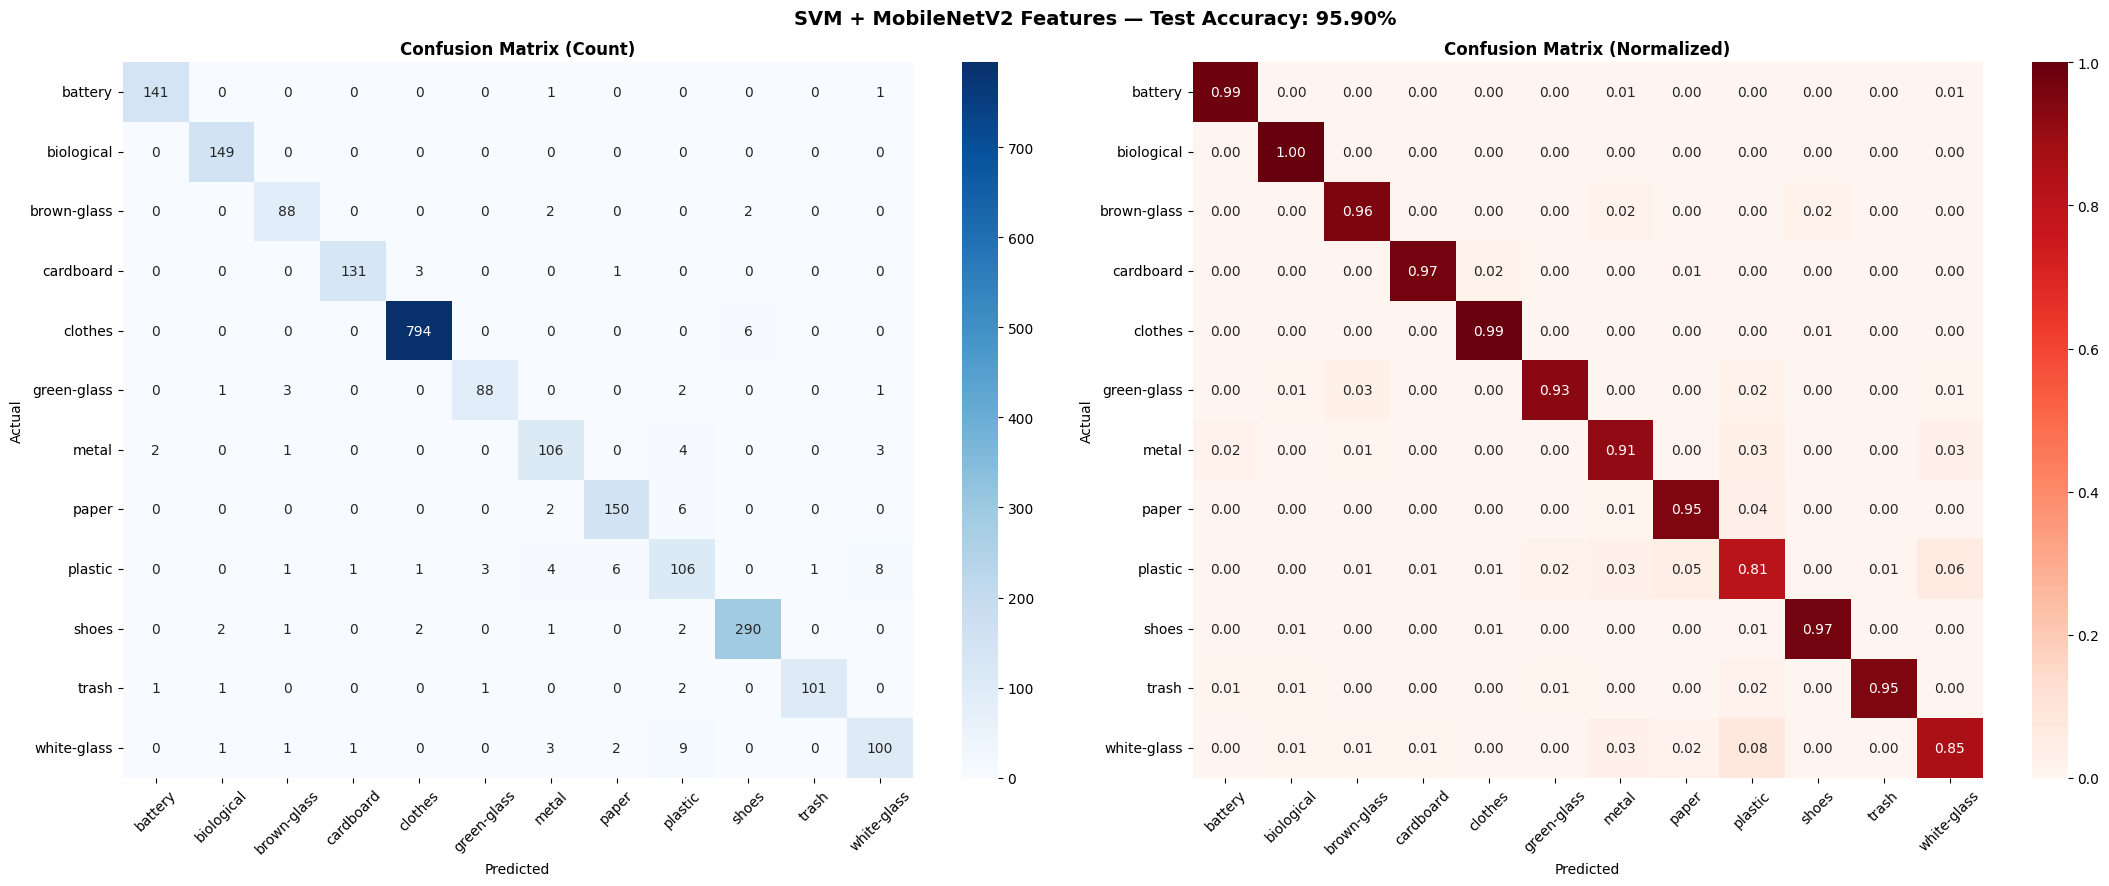

In [7]:
conf_matrix            = confusion_matrix(y_test, y_pred)
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

fig, (ax_count, ax_norm) = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_count)
ax_count.set_title('Confusion Matrix (Count)', fontweight='bold')
ax_count.set_xlabel('Predicted')
ax_count.set_ylabel('Actual')
ax_count.tick_params(axis='x', rotation=45)

sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax_norm)
ax_norm.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax_norm.set_xlabel('Predicted')
ax_norm.set_ylabel('Actual')
ax_norm.tick_params(axis='x', rotation=45)

plt.suptitle(f'SVM + MobileNetV2 Features — Test Accuracy: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **INFERENCE**

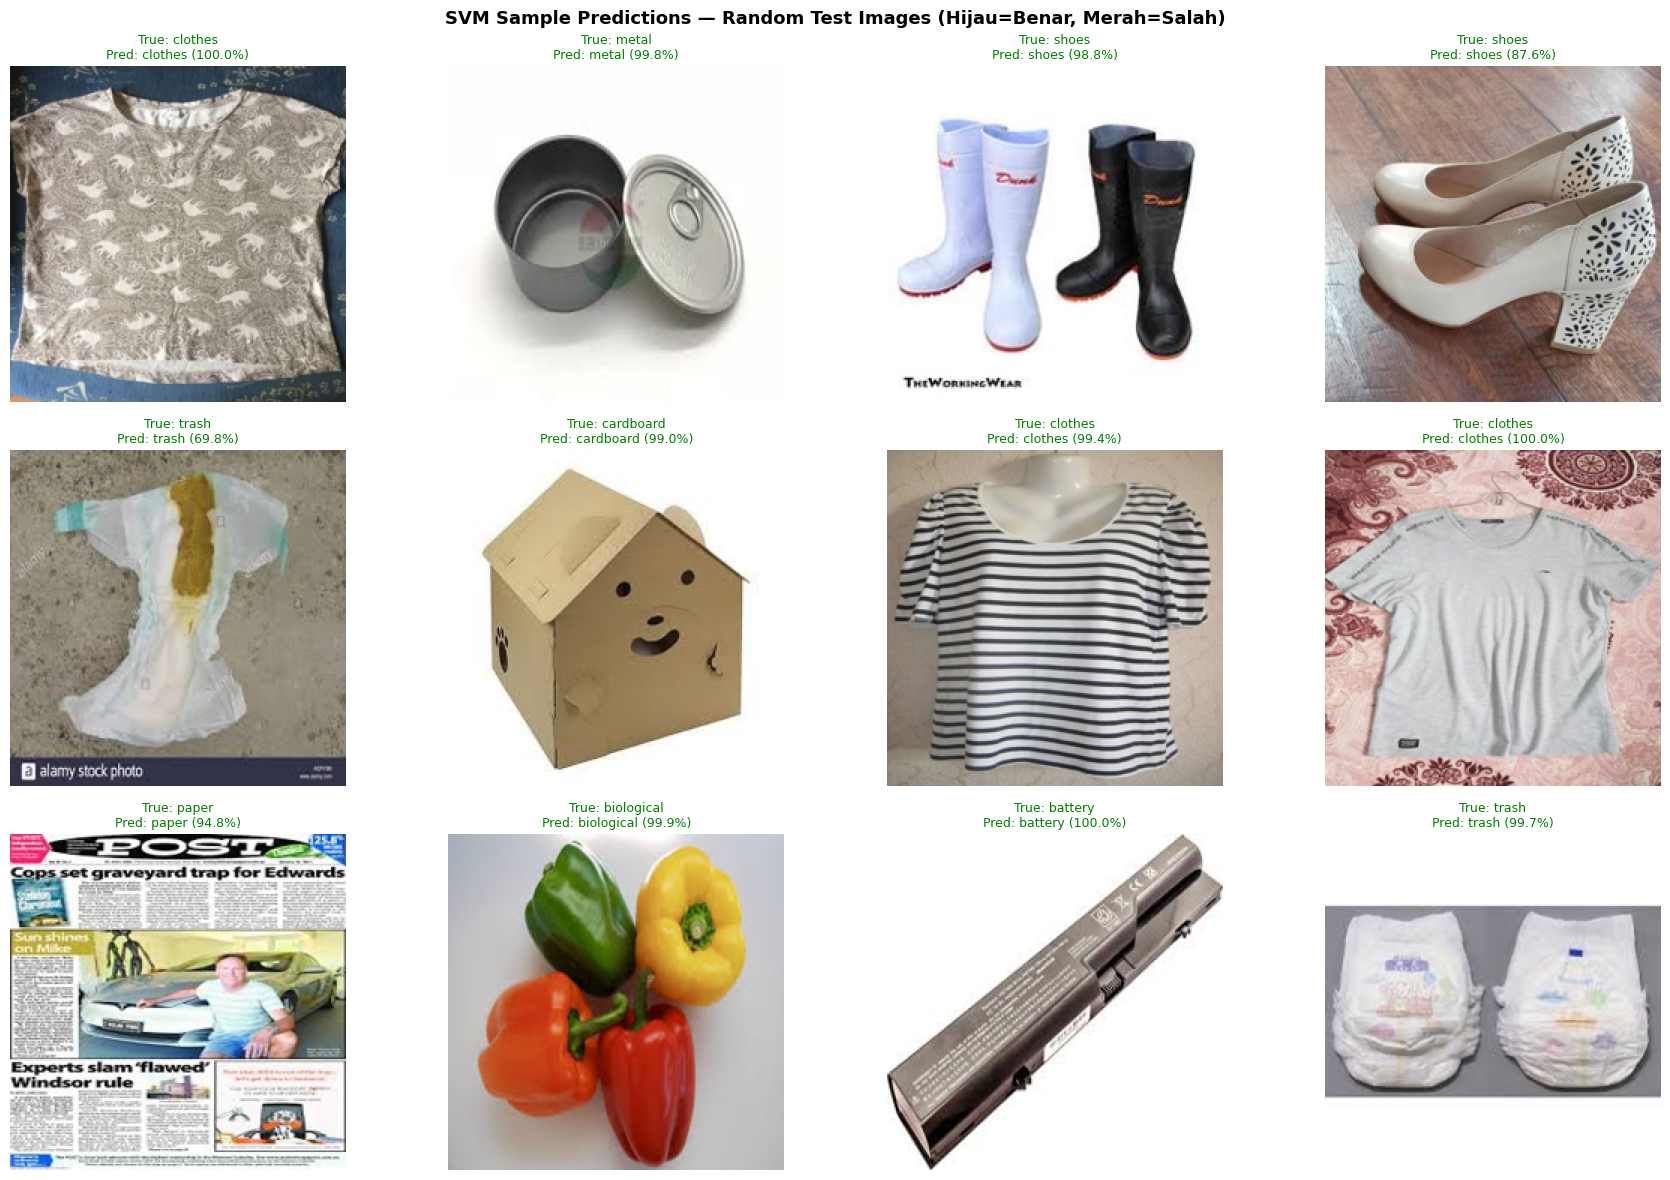

In [8]:
NUM_SAMPLE_PREDICTIONS = 12

try:
    extractor
except NameError:
    extractor = build_feature_extractor()

test_data_dir   = Path(TEST_DIR)
all_test_images = []
for class_folder in sorted(test_data_dir.iterdir()):
    if class_folder.is_dir():
        for img_path in class_folder.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                all_test_images.append((img_path, class_folder.name))

random.shuffle(all_test_images)
sampled = all_test_images[:NUM_SAMPLE_PREDICTIONS]

sample_images_raw  = []
sample_true_labels = []
for img_path, class_name in sampled:
    img = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    sample_images_raw.append(np.array(img, dtype=np.float32))
    sample_true_labels.append(class_name)

sample_input    = preprocess_input(np.array(sample_images_raw))
sample_features = extractor.predict(sample_input, verbose=0)
sample_preds    = svm_model.predict(sample_features)
sample_probs    = svm_model.predict_proba(sample_features)

cols = 4
rows = (NUM_SAMPLE_PREDICTIONS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i in range(NUM_SAMPLE_PREDICTIONS):
    true_label      = sample_true_labels[i]
    predicted_label = CLASS_NAMES[sample_preds[i]]
    confidence_pct  = np.max(sample_probs[i]) * 100
    is_correct      = true_label == predicted_label

    display_img = np.clip(sample_images_raw[i] / 255.0, 0, 1)
    axes[i].imshow(display_img)
    axes[i].set_title(
        f'True: {true_label}\nPred: {predicted_label} ({confidence_pct:.1f}%)',
        color='green' if is_correct else 'red',
        fontsize=9,
    )
    axes[i].axis('off')

for i in range(NUM_SAMPLE_PREDICTIONS, len(axes)):
    axes[i].axis('off')

plt.suptitle('SVM Sample Predictions — Random Test Images (Hijau=Benar, Merah=Salah)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()